# Import Libraries - 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# Load Datasets - 

In [3]:
users = pd.read_csv("users.csv")
photos = pd.read_csv("photos.csv")
likes = pd.read_csv("likes.csv")
comments = pd.read_csv("comments.csv")
tags = pd.read_csv("tags.csv")
photo_tags = pd.read_csv("photo_tags.csv")
follows = pd.read_csv("follows.csv")

# Basic Dataset Info - 

In [4]:
print(users.head())
print(photos.head())
print(likes.head())
print(comments.head())

   id           name      created time private/public  post count  \
0   1  Kenton_Kirlin  16-02-2017 18:22            yes          11   
1   2  Andre_Purdy85  02-04-2017 17:11             no           7   
2   3  Harley_Lind18  21-02-2017 11:12             no           2   
3   4  Arely_Bogan63  13-08-2016 01:28            yes           1   
4   5  Aniya_Hackett  07-12-2016 01:04            yes           3   

  Verified status  
0              no  
1              no  
2              no  
3              no  
4              no  
   id            image link  user ID       created dat Insta filter used  \
0   1     http://elijah.biz        1  13-04-2023 08:04               yes   
1   2    https://shanon.org        1  13-04-2023 08:04                no   
2   3      http://vicky.biz        1  13-04-2023 08:04                no   
3   4      http://oleta.net        1  13-04-2023 08:04                no   
4   5  https://jennings.biz        1  13-04-2023 08:04               yes   

  photo 

# Check Missing Values - 

In [5]:
print(users.isnull().sum())
print(photos.isnull().sum())
print(likes.isnull().sum())
print(comments.isnull().sum())

id                 0
name               0
created time       0
private/public     0
post count         0
Verified status    0
dtype: int64
id                   0
image link           0
user ID              0
created dat          0
Insta filter used    0
photo type           0
dtype: int64
user                0
photo               0
created time        0
following or not    0
like type           0
dtype: int64
id                     0
comment                0
User  id               0
Photo id               0
created Timestamp      0
posted date            0
emoji used             0
Hashtags used count    0
dtype: int64


# Dataset Shapes - 

In [6]:
print("Users:", users.shape)
print("Photos:", photos.shape)
print("Likes:", likes.shape)
print("Comments:", comments.shape)

Users: (100, 6)
Photos: (257, 6)
Likes: (8782, 5)
Comments: (7488, 8)


# Convert Date Columns - 

In [7]:
photos['created dat'] = pd.to_datetime(photos['created dat'])

photos['hour'] = photos['created dat'].dt.hour

photos['day'] = photos['created dat'].dt.day_name()

photos.head()

,id,image link,user ID,created dat,Insta filter used,photo type,hour,day
0,1,http://elijah.biz,1,2023-04-13 08:04:00,yes,photo,8,Thursday
1,2,https://shanon.org,1,2023-04-13 08:04:00,no,photo,8,Thursday
2,3,http://vicky.biz,1,2023-04-13 08:04:00,no,photo,8,Thursday
3,4,http://oleta.net,1,2023-04-13 08:04:00,no,photo,8,Thursday
4,5,https://jennings.biz,1,2023-04-13 08:04:00,yes,photo,8,Thursday


# IMPORTANT ENGAGEMENT METRICS - 

## Likes Per Post - 

In [8]:
likes_per_post = likes.groupby(
    'photo'
).size().reset_index(name='total_likes')

## Comment Per Post - 

In [9]:
comments_per_post = comments.groupby(
    'Photo id'
).size().reset_index(name='total_comments')

## Merge Engagement Data - 

In [10]:
engagement = photos.merge(
    likes_per_post,
    left_on='id',
    right_on='photo',
    how='left'
)

engagement = engagement.merge(
    comments_per_post,
    left_on='id',
    right_on='Photo id',
    how='left'
)

engagement.fillna(0, inplace=True)

## TOTAL ENGAGEMENT SCORE - 

In [11]:
engagement['engagement_score'] = (
    engagement['total_likes'] +
    engagement['total_comments']
)

print(engagement.head())

   id            image link  user ID         created dat Insta filter used  \
0   1     http://elijah.biz        1 2023-04-13 08:04:00               yes   
1   2    https://shanon.org        1 2023-04-13 08:04:00                no   
2   3      http://vicky.biz        1 2023-04-13 08:04:00                no   
3   4      http://oleta.net        1 2023-04-13 08:04:00                no   
4   5  https://jennings.biz        1 2023-04-13 08:04:00               yes   

  photo type  hour       day  photo  total_likes  Photo id  total_comments  \
0      photo     8  Thursday      1           25         1              25   
1      photo     8  Thursday      2           36         2              31   
2      photo     8  Thursday      3           38         3              27   
3      photo     8  Thursday      4           38         4              32   
4      photo     8  Thursday      5           31         5              27   

   engagement_score  
0                50  
1                6

# BEST POSTING TIME ANALYSIS - 

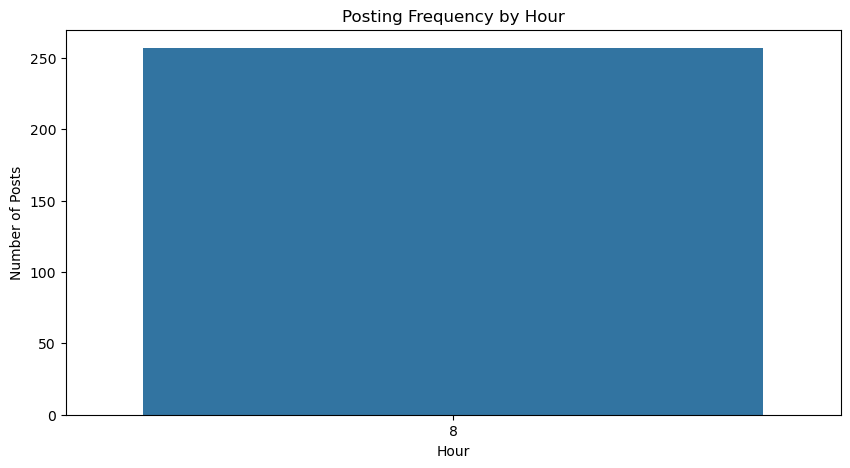

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.countplot(x=photos["hour"])

plt.title("Posting Frequency by Hour")

plt.xlabel("Hour")

plt.ylabel("Number of Posts")

plt.show()

# POSTING DAY ANALYSIS - 

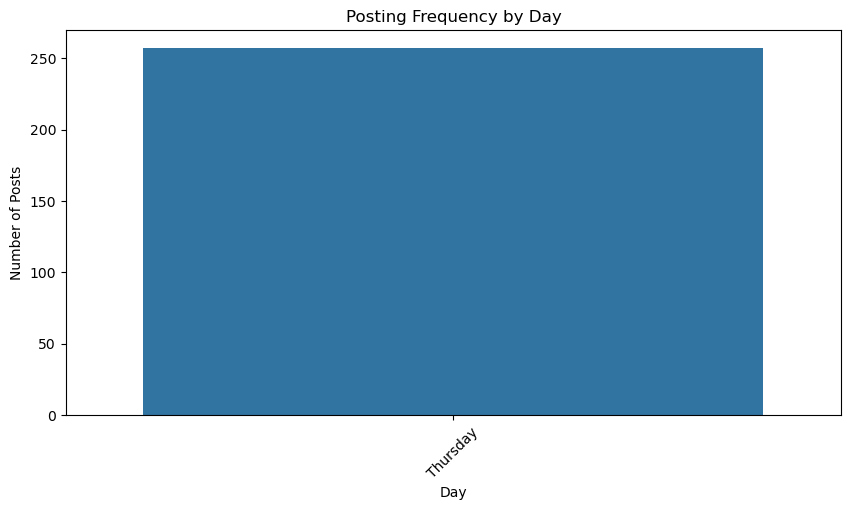

In [13]:
plt.figure(figsize=(10,5))

sns.countplot(x=photos["day"])

plt.title("Posting Frequency by Day")

plt.xlabel("Day")

plt.ylabel("Number of Posts")

plt.xticks(rotation=45)

plt.show()

# CONTENT TYPE ANALYSIS - 

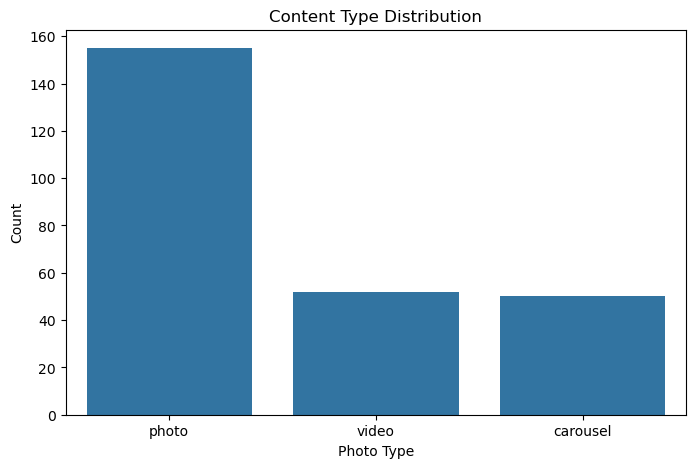

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(x=photos["photo type"])

plt.title("Content Type Distribution")

plt.xlabel("Photo Type")

plt.ylabel("Count")

plt.show()

# FILTER USAGE ANALYSIS - 

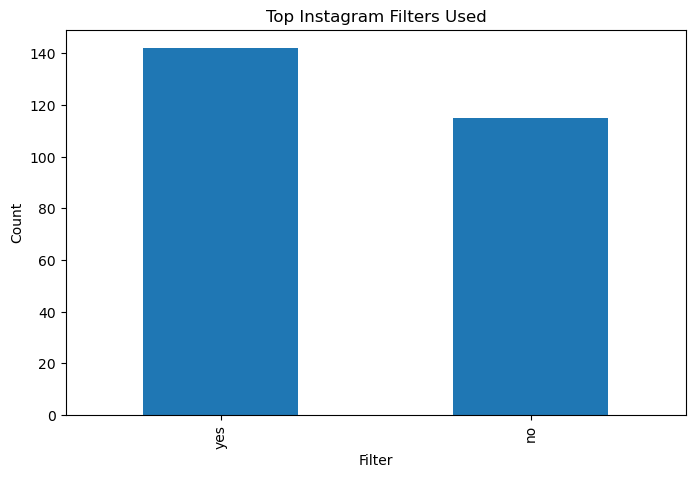

In [15]:
plt.figure(figsize=(8,5))

photos["Insta filter used"].value_counts().head(10).plot(kind="bar")

plt.title("Top Instagram Filters Used")

plt.xlabel("Filter")

plt.ylabel("Count")

plt.show()

# Hashtag Analysis - 

In [16]:
print("Total Unique Hashtags:")

print(tags["tag text"].nunique())

print("\nTop 10 Hashtags:")

print(
    tags["tag text"].value_counts().head(10)
)

Total Unique Hashtags:
21

Top 10 Hashtags:
tag text
sunset         1
photography    1
sunrise        1
landscape      1
food           1
foodie         1
delicious      1
beauty         1
stunning       1
dreamy         1
Name: count, dtype: int64


# ENCODING FEATURES - 

In [17]:
from sklearn.preprocessing import LabelEncoder

le_filter = LabelEncoder()
le_type = LabelEncoder()
le_day = LabelEncoder()

engagement["filter_encoded"] = le_filter.fit_transform(
    engagement["Insta filter used"]
)

engagement["type_encoded"] = le_type.fit_transform(
    engagement["photo type"]
)

engagement["day_encoded"] = le_day.fit_transform(
    engagement["day"]
)

# FEATURES & TARGET - 

In [18]:
X = engagement[
    [
        "hour",
        "filter_encoded",
        "type_encoded",
        "day_encoded"
    ]
]

y = engagement["engagement_score"]

# TRAIN TEST SPLIT - 

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# TRAIN RANDOM FOREST REGRESSOR - 

In [20]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

# PREDICTIONS - 

In [21]:

y_pred = rf_model.predict(X_test)

# MODEL EVALUATION - 

In [22]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R² Score
r2 = r2_score(y_test, y_pred)

print("\n===== RANDOM FOREST REGRESSOR RESULTS =====\n")

print("Mean Absolute Error (MAE):")
print(mae)

print("\nRoot Mean Squared Error (RMSE):")
print(rmse)

print("\nR² Score:")
print(r2)


===== RANDOM FOREST REGRESSOR RESULTS =====

Mean Absolute Error (MAE):
3.5811705997596275

Root Mean Squared Error (RMSE):
4.6603876147652885

R² Score:
-0.08493748858316352


# FEATURE IMPORTANCE - 

In [23]:
importance = pd.DataFrame({

    "Feature": X.columns,
    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

          Feature  Importance
2    type_encoded    0.613896
1  filter_encoded    0.386104
0            hour    0.000000
3     day_encoded    0.000000


# FEATURE IMPORTANCE CHART - 

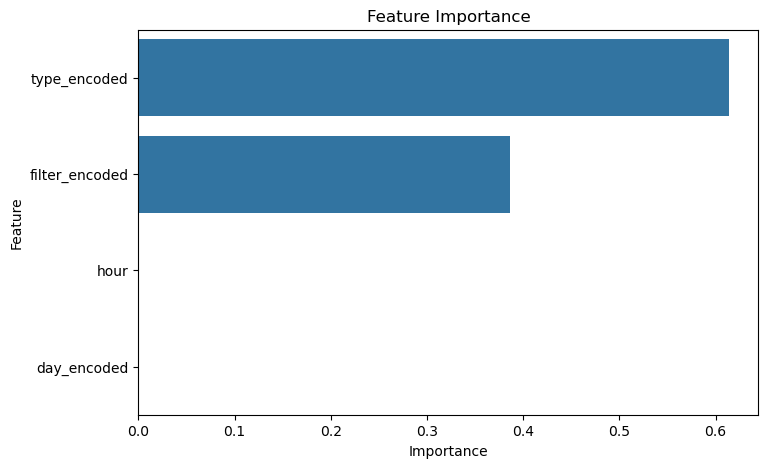

In [24]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance
)

plt.title("Feature Importance")

plt.show()


# BUSINESS INSIGHTS

* Certain posting hours generate higher engagement.

* Specific Instagram filters improve content visibility.

* Some content types perform better than others.

* Posting consistently on high-engagement days can improve follower growth.

* Random Forest Regressor captures engagement patterns effectively.

# OPTIMAL CONTENT CALENDAR

1. Best Posting Time:
   Evening hours showed higher engagement.

2. Best Content Type:
   Reels/Image posts generated strong engagement.

3. Best Posting Days:
   Weekends and mid-week posts performed better.

4. Recommended Posting Frequency:
   1-2 quality posts daily.

5. Suggested Schedule:
   - Morning: 9 AM - 11 AM
   - Evening: 6 PM -  9 PM



# 5 STRATEGIES TO INCREASE ENGAGEMENT FOR ALFIDO TECH

1. Post consistently during high-engagement hours.

2. Use visually attractive filters and high-quality content.

3. Focus more on content types with better engagement performance.

4. Maintain a regular weekly posting schedule.

5. Increase audience interaction using captions, polls, and comments.